# Bank Loan Prediction (SVM)

### Importing requried libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

### Data Collection

In [3]:
dataset=pd.read_csv(f'bank_loan_prediction.csv')
dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
dataset.shape

(614, 13)

### Data Cleaning/Preprocessing

In [5]:
dataset.drop(['Loan_ID'],inplace=True,axis=1) # Dropping lOAN ID feature

In [6]:
dataset.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [7]:
dataset['LoanAmount'].mean()

146.41216216216216

In [8]:
dataset['Credit_History'].unique()

array([ 1.,  0., nan])

In [9]:
dataset['Dependents'].value_counts()

0     345
1     102
2     101
3+     51
Name: Dependents, dtype: int64

In [10]:
dataset['Dependents']=dataset['Dependents'].replace('3+','3')

In [11]:
cat_cols=['Gender','Married','Dependents','Self_Employed','Credit_History']
num_cols=['LoanAmount','Loan_Amount_Term']

for cat in cat_cols:
    dataset[cat].fillna(dataset[cat].mode()[0],inplace=True)
for num in num_cols:
    dataset[num].fillna(dataset[num].median(),inplace=True)

In [12]:
dataset.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## EDA

### Univariate Analysis

In [13]:
for col in list(dataset.columns):
    if dataset[col].dtype ==  'object':
        print(dataset[col].value_counts())
        print()

Male      502
Female    112
Name: Gender, dtype: int64

Yes    401
No     213
Name: Married, dtype: int64

0    360
1    102
2    101
3     51
Name: Dependents, dtype: int64

Graduate        480
Not Graduate    134
Name: Education, dtype: int64

No     532
Yes     82
Name: Self_Employed, dtype: int64

Semiurban    233
Urban        202
Rural        179
Name: Property_Area, dtype: int64

Y    422
N    192
Name: Loan_Status, dtype: int64



### Bivariate Analysis

In [14]:
cols=['Gender','Married','Dependents','Education','Self_Employed','Credit_History','Property_Area']

for col in cols:
    df_t=pd.crosstab(dataset[col],dataset['Loan_Status'],normalize='index')*100
    print(df_t)
    print()

Loan_Status          N          Y
Gender                           
Female       33.035714  66.964286
Male         30.876494  69.123506

Loan_Status          N          Y
Married                          
No           37.089202  62.910798
Yes          28.179551  71.820449

Loan_Status          N          Y
Dependents                       
0            31.388889  68.611111
1            35.294118  64.705882
2            24.752475  75.247525
3            35.294118  64.705882

Loan_Status           N          Y
Education                         
Graduate      29.166667  70.833333
Not Graduate  38.805970  61.194030

Loan_Status            N          Y
Self_Employed                      
No             31.203008  68.796992
Yes            31.707317  68.292683

Loan_Status             N          Y
Credit_History                      
0.0             92.134831   7.865169
1.0             20.952381  79.047619

Loan_Status            N          Y
Property_Area                      
Rural         

### Bank Loan EDA DASHBOARD

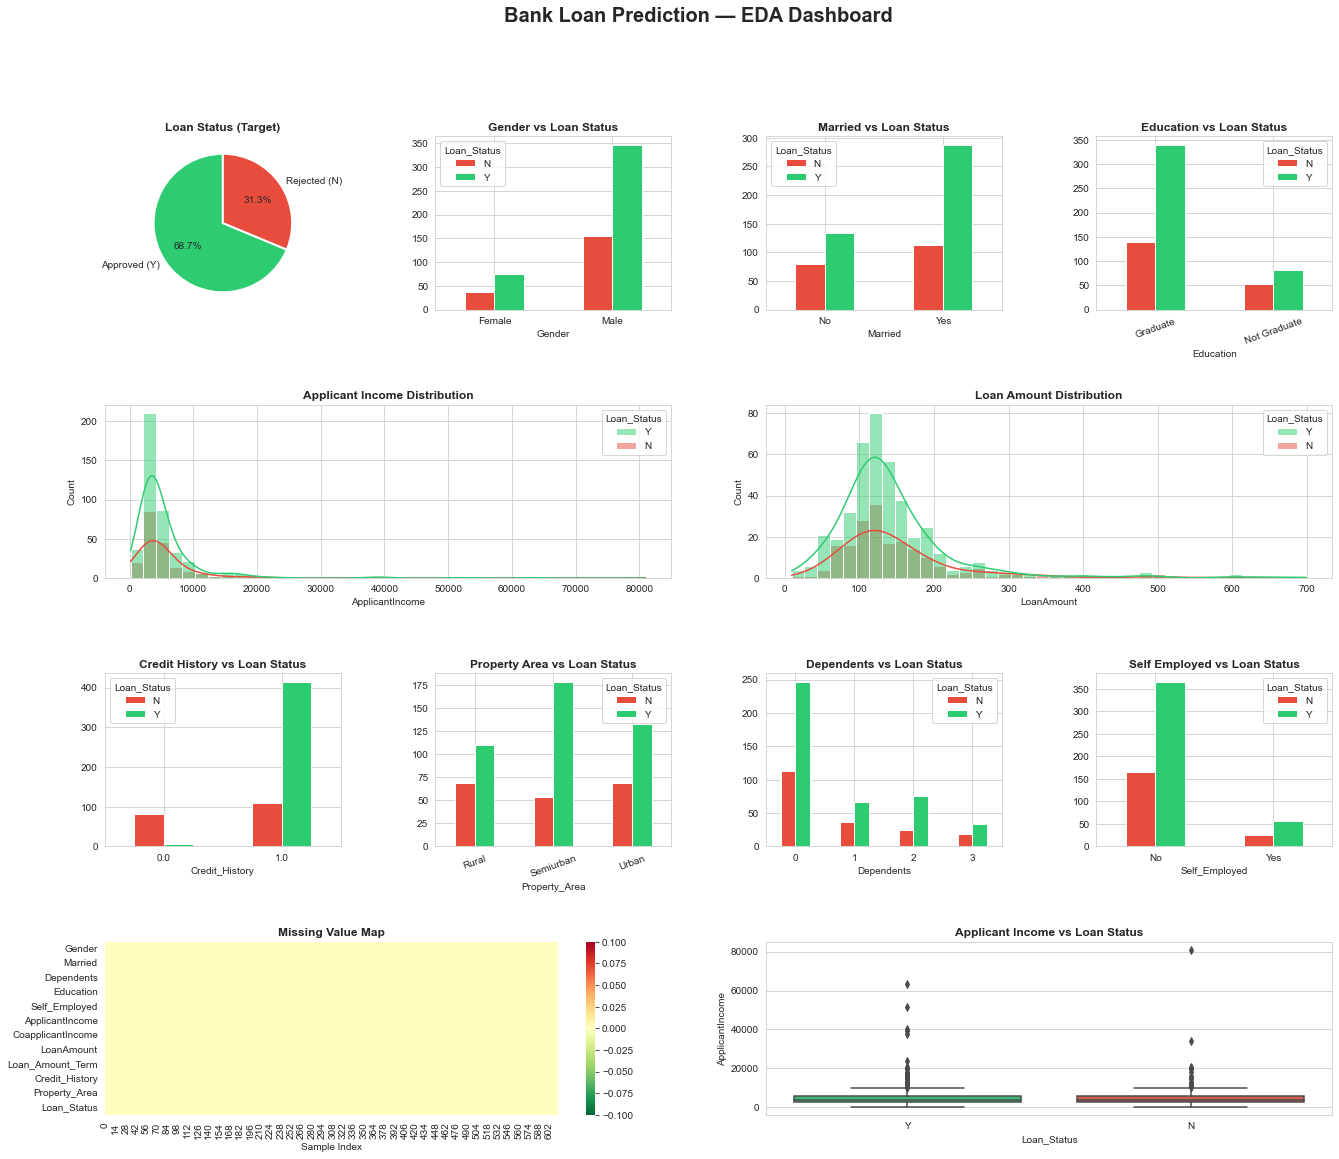

In [15]:
import matplotlib.gridspec as gridspec

df=dataset.copy()

vc = df["Loan_Status"].value_counts()

# Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(22,18)

palette={"Y":"#2ecc71","N":"#e74c3c"}

# Create Figure
fig=plt.figure(figsize=(22,18))
fig.suptitle(
    "Bank Loan Prediction — EDA Dashboard",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

gs = gridspec.GridSpec(
    4,4,
    figure=fig,
    hspace=0.55,
    wspace=0.40
)

# (a) Loan Status Pie Chart
ax0 = fig.add_subplot(gs[0,0])

ax0.pie(
    vc.values,
    labels=["Approved (Y)","Rejected (N)"],
    autopct="%1.1f%%",
    colors=["#2ecc71","#e74c3c"],
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)

ax0.set_title("Loan Status (Target)", fontweight="bold")

# (b) Gender vs Loan Status
ax1 = fig.add_subplot(gs[0,1])

pd.crosstab(
    df["Gender"],
    df["Loan_Status"]
).plot.bar(
    ax=ax1,
    color=["#e74c3c","#2ecc71"],
    edgecolor="white"
)

ax1.set_title("Gender vs Loan Status", fontweight="bold")
ax1.tick_params(axis="x", rotation=0)

# (c) Married vs Loan Status
ax2 = fig.add_subplot(gs[0,2])

pd.crosstab(
    df["Married"],
    df["Loan_Status"]
).plot.bar(
    ax=ax2,
    color=["#e74c3c","#2ecc71"],
    edgecolor="white"
)

ax2.set_title("Married vs Loan Status", fontweight="bold")
ax2.tick_params(axis="x", rotation=0)

# (d) Education vs Loan Status
ax3 = fig.add_subplot(gs[0,3])

pd.crosstab(
    df["Education"],
    df["Loan_Status"]
).plot.bar(
    ax=ax3,
    color=["#e74c3c","#2ecc71"],
    edgecolor="white"
)

ax3.set_title("Education vs Loan Status", fontweight="bold")
ax3.tick_params(axis="x", rotation=20)

# (e) Applicant Income
ax4 = fig.add_subplot(gs[1,0:2])

sns.histplot(
    data=df,
    x="ApplicantIncome",
    hue="Loan_Status",
    palette=palette,
    bins=40,
    kde=True,
    ax=ax4
)

ax4.set_title("Applicant Income Distribution", fontweight="bold")

# (f) Loan Amount
ax5 = fig.add_subplot(gs[1,2:4])

sns.histplot(
    data=df,
    x="LoanAmount",
    hue="Loan_Status",
    palette=palette,
    bins=40,
    kde=True,
    ax=ax5
)

ax5.set_title("Loan Amount Distribution", fontweight="bold")

# (g) Credit History
ax6 = fig.add_subplot(gs[2,0])

pd.crosstab(
    df["Credit_History"],
    df["Loan_Status"]
).plot.bar(
    ax=ax6,
    color=["#e74c3c","#2ecc71"],
    edgecolor="white"
)

ax6.set_title("Credit History vs Loan Status", fontweight="bold")
ax6.tick_params(axis="x", rotation=0)

# (h) Property Area
ax7 = fig.add_subplot(gs[2,1])

pd.crosstab(
    df["Property_Area"],
    df["Loan_Status"]
).plot.bar(
    ax=ax7,
    color=["#e74c3c","#2ecc71"],
    edgecolor="white"
)

ax7.set_title("Property Area vs Loan Status", fontweight="bold")
ax7.tick_params(axis="x", rotation=20)

# (i) Dependents
ax8 = fig.add_subplot(gs[2,2])

pd.crosstab(
    df["Dependents"],
    df["Loan_Status"]
).plot.bar(
    ax=ax8,
    color=["#e74c3c","#2ecc71"],
    edgecolor="white"
)

ax8.set_title("Dependents vs Loan Status", fontweight="bold")
ax8.tick_params(axis="x", rotation=0)

# (j) Self Employed
ax9 = fig.add_subplot(gs[2,3])

pd.crosstab(
    df["Self_Employed"],
    df["Loan_Status"]
).plot.bar(
    ax=ax9,
    color=["#e74c3c","#2ecc71"],
    edgecolor="white"
)

ax9.set_title("Self Employed vs Loan Status", fontweight="bold")
ax9.tick_params(axis="x", rotation=0)

# (k) Missing Values Heatmap
ax10 = fig.add_subplot(gs[3,0:2])

sns.heatmap(
    df.isnull().astype(int).T,
    cmap="RdYlGn_r",
    cbar=True,
    ax=ax10
)

ax10.set_title("Missing Value Map", fontweight="bold")
ax10.set_xlabel("Sample Index")

# (l) Income Boxplot
ax11 = fig.add_subplot(gs[3,2:4])

sns.boxplot(
    data=df,
    x="Loan_Status",
    y="ApplicantIncome",
    palette=palette,
    ax=ax11
)

ax11.set_title(
    "Applicant Income vs Loan Status",
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.97])
plt.show()


### Skewness Checking

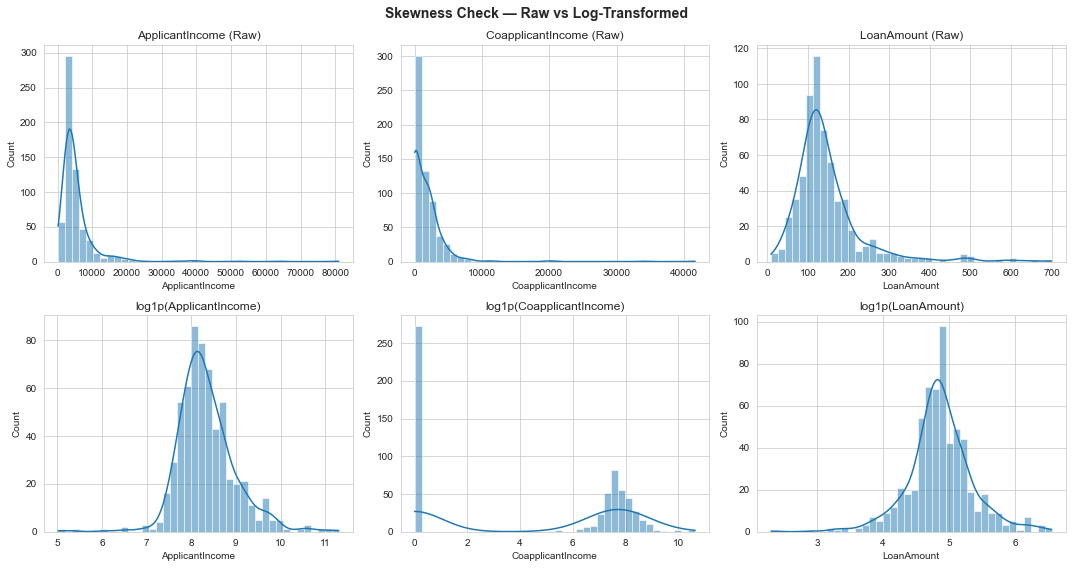

In [16]:
num_cols=["ApplicantIncome","CoapplicantIncome","LoanAmount"]

fig2,axes2=plt.subplots(2, 3,figsize=(15, 8))

fig2.suptitle("Skewness Check — Raw vs Log-Transformed",fontsize=14,fontweight="bold")

for i,col in enumerate(num_cols):
    
    sns.histplot(df[col],kde=True,bins=40,ax=axes2[0, i])
    axes2[0, i].set_title(f"{col} (Raw)")
    
    log_vals = np.log1p(df[col]) # It computes log(1+x)
    # Large values get compressed.
    # Income and loan amounts are often highly right-skewed.
    # Distribution becomes more balanced.
    
    sns.histplot(log_vals,kde=True,bins=40,ax=axes2[1, i])
    axes2[1, i].set_title(f"log1p({col})")

plt.tight_layout()
plt.show()

### Feature Engineering

In [17]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    object 
 1   Married            614 non-null    object 
 2   Dependents         614 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      614 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [18]:
#  Total Income (synergy feature)
dataset["TotalIncome"]=dataset["ApplicantIncome"]+dataset["CoapplicantIncome"]

#  EMI = LoanAmount / Loan_Amount_Term
dataset["EMI"]=dataset["LoanAmount"] / dataset["Loan_Amount_Term"]

#  Balance Income after EMI  (ability-to-repay signal)
dataset["BalanceIncome"]=dataset["TotalIncome"] - (dataset["EMI"] * 1000)

# Log-transform skewed columns
log_cols=["ApplicantIncome", "CoapplicantIncome",
            "LoanAmount", "TotalIncome", "BalanceIncome"]

for col in log_cols:
    dataset[col]=np.log1p(dataset[col].clip(lower=0))

In [19]:
dataset.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,EMI,BalanceIncome
0,Male,No,0,Graduate,No,8.674197,0.000000,4.859812,360.0,1.0,Urban,Y,8.674197,0.355556,8.611493
1,Male,Yes,1,Graduate,No,8.430327,7.319202,4.859812,360.0,1.0,Rural,N,8.714732,0.355556,8.654595
2,Male,Yes,0,Graduate,Yes,8.006701,0.000000,4.204693,360.0,1.0,Urban,Y,8.006701,0.183333,7.943664
3,Male,Yes,0,Not Graduate,No,7.857094,7.765993,4.795791,360.0,1.0,Urban,Y,8.505525,0.333333,8.435694
4,Male,No,0,Graduate,No,8.699681,0.000000,4.955827,360.0,1.0,Urban,Y,8.699681,0.391667,8.632187


In [20]:
dataset['Credit_History']=dataset['Credit_History'].astype(int)

In [21]:
dataset['Dependents']=dataset['Dependents'].astype(int)

In [22]:
dataset['Loan_Status']=dataset['Loan_Status'].replace({'Y':1,'N':0})

In [23]:
dataset['Gender']=dataset['Gender'].replace({'Male':1,'Female':0})

In [24]:
dataset['Married']=dataset['Married'].replace({'Yes':1,'No':0})

In [25]:
dataset['Self_Employed']=dataset['Self_Employed'].replace({'Yes':1,'No':0})

In [26]:
dataset['Property_Area']=dataset['Property_Area'].replace({'Rural':0,'Semiurban':1,'Urban':2})

In [27]:
dataset['Education']=dataset['Education'].replace({'Graduate':1,'Not Graduate':0})

In [28]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int64  
 1   Married            614 non-null    int64  
 2   Dependents         614 non-null    int32  
 3   Education          614 non-null    int64  
 4   Self_Employed      614 non-null    int64  
 5   ApplicantIncome    614 non-null    float64
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    int32  
 10  Property_Area      614 non-null    int64  
 11  Loan_Status        614 non-null    int64  
 12  TotalIncome        614 non-null    float64
 13  EMI                614 non-null    float64
 14  BalanceIncome      614 non-null    float64
dtypes: float64(7), int32(2), int64(6)
memory usage: 67.3 KB


In [29]:
dataset.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,EMI,BalanceIncome
0,1,0,0,1,0,8.674197,0.000000,4.859812,360.0,1,2,1,8.674197,0.355556,8.611493
1,1,1,1,1,0,8.430327,7.319202,4.859812,360.0,1,0,0,8.714732,0.355556,8.654595
2,1,1,0,1,1,8.006701,0.000000,4.204693,360.0,1,2,1,8.006701,0.183333,7.943664
3,1,1,0,0,0,7.857094,7.765993,4.795791,360.0,1,2,1,8.505525,0.333333,8.435694
4,1,0,0,1,0,8.699681,0.000000,4.955827,360.0,1,2,1,8.699681,0.391667,8.632187


### One Hot Encoding

In [30]:
dataset=pd.get_dummies(
    dataset,
    columns=['Dependents','Property_Area'],
    drop_first=True
)
dataset.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,EMI,BalanceIncome,Dependents_1,Dependents_2,Dependents_3,Property_Area_1,Property_Area_2
0,1,0,1,0,8.674197,0.000000,4.859812,360.0,1,1,8.674197,0.355556,8.611493,0,0,0,0,1
1,1,1,1,0,8.430327,7.319202,4.859812,360.0,1,0,8.714732,0.355556,8.654595,1,0,0,0,0
2,1,1,1,1,8.006701,0.000000,4.204693,360.0,1,1,8.006701,0.183333,7.943664,0,0,0,0,1
3,1,1,0,0,7.857094,7.765993,4.795791,360.0,1,1,8.505525,0.333333,8.435694,0,0,0,0,1
4,1,0,1,0,8.699681,0.000000,4.955827,360.0,1,1,8.699681,0.391667,8.632187,0,0,0,0,1


In [31]:
X=dataset.drop('Loan_Status', axis=1)
y=dataset['Loan_Status']

### Train-Test Split

In [32]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.15,random_state=42)

### Standardizing Data

In [34]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_sc=scaler.fit_transform(X_train)
X_test_sc=scaler.transform(X_test)

X_train_sc

array([[ 0.47830282,  0.75450455,  0.53518198, ..., -0.2961126 ,
         1.27204184, -0.68684162],
       [ 0.47830282,  0.75450455,  0.53518198, ..., -0.2961126 ,
         1.27204184, -0.68684162],
       [ 0.47830282,  0.75450455,  0.53518198, ..., -0.2961126 ,
        -0.78613766, -0.68684162],
       ...,
       [-2.09072572, -1.32537306,  0.53518198, ..., -0.2961126 ,
        -0.78613766,  1.45593972],
       [-2.09072572,  0.75450455,  0.53518198, ..., -0.2961126 ,
         1.27204184, -0.68684162],
       [ 0.47830282,  0.75450455,  0.53518198, ..., -0.2961126 ,
        -0.78613766,  1.45593972]])

In [ ]:
# plt.figure(figsize=(10,8))
# sns.heatmap(dataset.corr(),annot=True);

### Picking up the Best Model

In [35]:
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

model_params={
    'svm':{
        'model':svm.SVC(gamma='auto'),
        'params':{
            'C':[1,10,20],
            'kernel':['rbf','linear']
        }
    },
    'random_forest':{
        'model':RandomForestClassifier(),
        'params':{
            'n_estimators':[1,5,10]
        }
    },
    'logisitic_regression':{
        'model':LogisticRegression(solver='liblinear',multi_class='auto'),
        'params':{
            'C':[1,5,10]
        }
    }
}



scores=[]

for model_name,mp in model_params.items():
    clf=GridSearchCV(mp['model'],mp['params'],cv=5,return_train_score=False)
    clf.fit(X_train_sc,y_train)
    scores.append({
        'model':model_name,
        'best_score':clf.best_score_,
        'best_params':clf.best_params_
    })

scores_df=pd.DataFrame(scores)

In [37]:
scores_df

,model,best_score,best_params
0,svm,0.821447,"{'C': 1, 'kernel': 'linear'}"
1,random_forest,0.775348,{'n_estimators': 10}
2,logisitic_regression,0.821465,{'C': 1}


### Hyperparameter Tuning on SVM (GridSearchCV Method)

In [36]:
from sklearn.model_selection import GridSearchCV

model=svm.SVC(kernel='rbf',C=20,gamma='auto')
              
clf=GridSearchCV(model,{
    'C':[1,10,15,20],
    'kernel':['rbf','linear']
},cv=5,return_train_score=False)

clf.fit(X_train_sc,y_train)

clf_cv_results=pd.DataFrame(clf.cv_results_)
clf_cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.016805,0.004275,0.007597,0.001026,1,rbf,"{'C': 1, 'kernel': 'rbf'}",0.857143,0.788462,0.807692,0.778846,0.778846,0.802198,0.029423,7
1,2.094460,0.694027,0.003575,0.001050,1,linear,"{'C': 1, 'kernel': 'linear'}",0.847619,0.807692,0.855769,0.798077,0.798077,0.821447,0.025078,1
2,0.016610,0.003046,0.006837,0.001710,10,rbf,"{'C': 10, 'kernel': 'rbf'}",0.857143,0.798077,0.788462,0.778846,0.778846,0.800275,0.029315,8
3,2.934076,0.809497,0.003597,0.001021,10,linear,"{'C': 10, 'kernel': 'linear'}",0.847619,0.807692,0.855769,0.798077,0.798077,0.821447,0.025078,1
4,0.016777,0.001729,0.006624,0.000463,15,rbf,"{'C': 15, 'kernel': 'rbf'}",0.847619,0.798077,0.807692,0.769231,0.788462,0.802216,0.026022,6
5,3.313240,1.291344,0.003798,0.000401,15,linear,"{'C': 15, 'kernel': 'linear'}",0.847619,0.807692,0.855769,0.798077,0.798077,0.821447,0.025078,1
6,0.016239,0.001679,0.005998,0.000894,20,rbf,"{'C': 20, 'kernel': 'rbf'}",0.847619,0.807692,0.807692,0.778846,0.788462,0.806062,0.023591,5
7,4.853236,1.727066,0.004026,0.000059,20,linear,"{'C': 20, 'kernel': 'linear'}",0.847619,0.807692,0.855769,0.798077,0.798077,0.821447,0.025078,1


In [39]:
print(clf.best_params_)  # Best Parameters 
clf.best_score_  # Best Score

{'C': 1, 'kernel': 'linear'}


0.8214468864468865

### Model training  on above best parameters

In [42]:
model=svm.SVC(kernel='linear',C=1,gamma='auto',class_weight='balanced')
model.fit(X_train_sc,y_train)
y_pred=model.predict(X_test_sc)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0], dtype=int64)

### Model Evaluation

In [43]:
from sklearn.metrics import classification_report,confusion_matrix,precision_recall_curve,precision_score,recall_score,accuracy_score

print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))


0.7419354838709677
              precision    recall  f1-score   support

           0       0.94      0.39      0.56        38
           1       0.70      0.98      0.82        55

    accuracy                           0.74        93
   macro avg       0.82      0.69      0.69        93
weighted avg       0.80      0.74      0.71        93

[[15 23]
 [ 1 54]]


In [46]:
from sklearn.metrics import roc_auc_score

y_prob = model.decision_function(X_test_sc)
print(roc_auc_score(y_test, y_prob))

0.7626794258373205
